In [49]:
#Импорты 

from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import re

#Задание 1. Реализация базового класса Account
class Account:
    _account_counter = 1000  #счётчик счетов

    def __init__(self, account_holder, balance=0):
        self.validate_holder(account_holder)
        if balance < 0:
            raise ValueError("Баланс не может быть отрицательным")

        Account._account_counter += 1
        self.holder = account_holder
        self.account_number = f"ACC-{Account._account_counter}"
        self._balance = balance
        self.operations_history = []

    #Проверка имени клиента
    def validate_holder(self, name):
        if not re.match(r'^[А-ЯA-Z][а-яa-z]+ [А-ЯA-Z][а-яa-z]+$', name):
            raise ValueError("Имя должно быть в формате 'Имя Фамилия'")

    #Пополнение
    def deposit(self, amount):
        if amount <= 0:
            raise ValueError("Сумма должна быть положительной")
        self._balance += amount
        self._log_operation("deposit", amount, "success")

    #Снятие
    def withdraw(self, amount):
        if amount <= 0:
            raise ValueError("Сумма должна быть положительной")
        if amount > self._balance:
            self._log_operation("withdraw", amount, "fail")
            print("Недостаточно средств")
            return
        self._balance -= amount
        self._log_operation("withdraw", amount, "success")

    #Запись операции в историю
    def _log_operation(self, op_type, amount, status):
        self.operations_history.append({
            "type": op_type,
            "amount": amount,
            "datetime": datetime.now(),
            "balance_after": self._balance,
            "status": status
        })

    #Актуальный баланс
    def get_balance(self):
        return self._balance

    #Визуализация
    def get_history(self):
        return pd.DataFrame(self.operations_history)

    # Визуализация истории
    def plot_history(self):
        df = pd.DataFrame(self.operations_history)
        if df.empty:
            print("Нет операций для отображения")
            return

        df = df.sort_values("datetime")
        plt.figure(figsize=(10, 5))
        plt.plot(df["datetime"], df["balance_after"], marker='o', linewidth=2)
        plt.title(f"Изменение баланса ({self.holder})", fontsize=14)
        plt.xlabel("Дата операции", fontsize=12)
        plt.ylabel("Баланс, ₽", fontsize=12)
        plt.xticks(rotation=30)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
        

#Задание 2. Реализация наследования
class CheckingAccount(Account):
    """Расчётный счёт"""
    account_type = "Checking"


class SavingsAccount(Account):
    """Сберегательный счёт"""
    account_type = "Savings"

    def withdraw(self, amount):
        if amount > self._balance * 0.5:
            self._log_operation("withdraw", amount, "fail")
            print("Нельзя снять больше 50% от баланса")
            return
        super().withdraw(amount)

    def apply_interest(self, rate):
        if rate < 0:
            raise ValueError("Ставка должна быть положительной")
        interest = self._balance * rate / 100
        self._balance += interest
        self._log_operation("interest", interest, "success")


Недостаточно средств
Баланс расчётного счёта: 1200


,type,amount,datetime,balance_after,status
0,deposit,500,2025-11-08 17:03:07.134226,1500,success
1,withdraw,300,2025-11-08 17:03:07.134316,1200,success
2,withdraw,2000,2025-11-08 17:03:07.134348,1200,fail


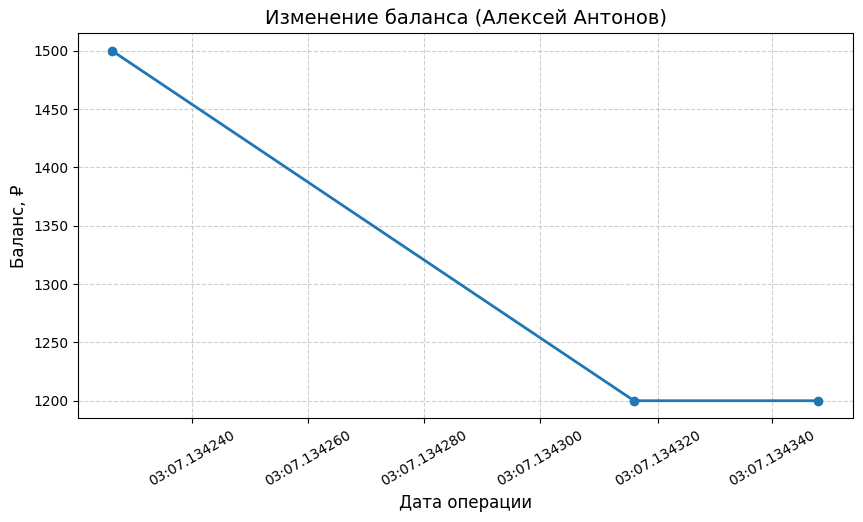


 Баланс сберегательного счёта: 963.0


,type,amount,datetime,balance_after,status
0,deposit,1000.0,2025-11-08 17:03:07.196592,3000.0,success
1,withdraw,1200.0,2025-11-08 17:03:07.196607,1800.0,success
2,withdraw,900.0,2025-11-08 17:03:07.196616,900.0,success
3,interest,63.0,2025-11-08 17:03:07.196626,963.0,success


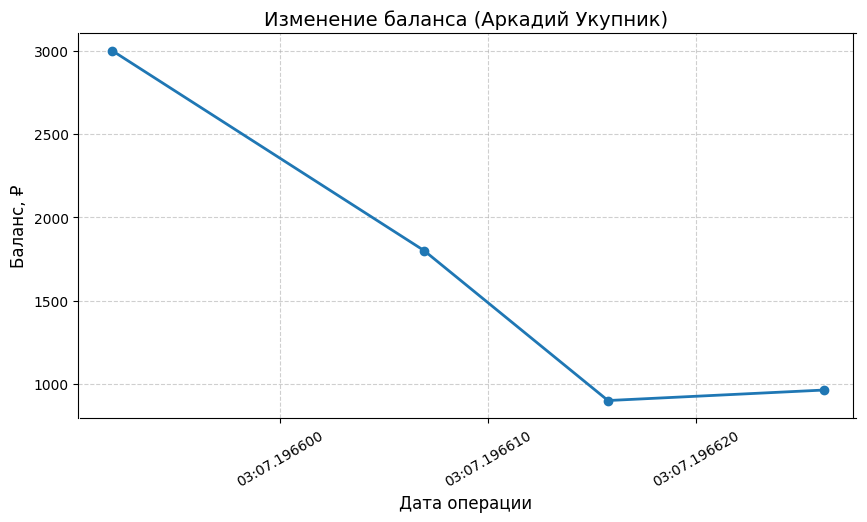

In [51]:
#Создание тестового расчётного счёта для демонстрации работы
acc1 = CheckingAccount("Алексей Антонов", 1000)
acc1.deposit(500)
acc1.withdraw(300)
acc1.withdraw(2000)  #недостаточно средств

print("Баланс расчётного счёта:", acc1.get_balance())
display(acc1.get_history())
acc1.plot_history()

#Создание тестового сберегательного счёта для демонстрации работы
acc2 = SavingsAccount("Аркадий Укупник", 2000)
acc2.deposit(1000)
acc2.withdraw(1200)  #превышает 50% — запрет
acc2.withdraw(900)   #разрешено
acc2.apply_interest(7)

print("\n Баланс сберегательного счёта:", acc2.get_balance())
display(acc2.get_history())
acc2.plot_history()
